In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


In [26]:
df = pd.read_csv("Titanic-Dataset.csv")
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
display(df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [29]:
df.shape

(891, 12)

In [30]:
# Missing values handling
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop('Cabin', axis=1, inplace=True)

/tmp/ipykernel_1219/3891752464.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1219/3891752464.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [31]:
# Display statistical summary of numerical columns
print('Statistical Summary:')
display(df.describe())

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


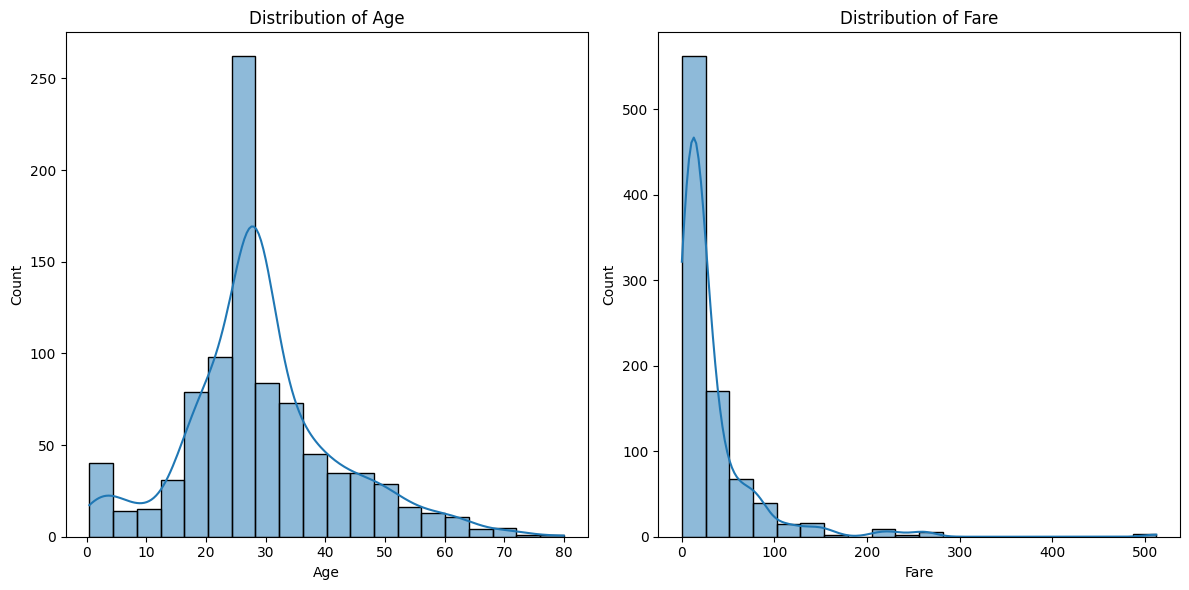

In [32]:
plt.figure(figsize=(12, 6))

# Distribution of Age
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

# Distribution of Fare
plt.subplot(1, 2, 2)
sns.histplot(df['Fare'], bins=20, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1219/3623386840.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


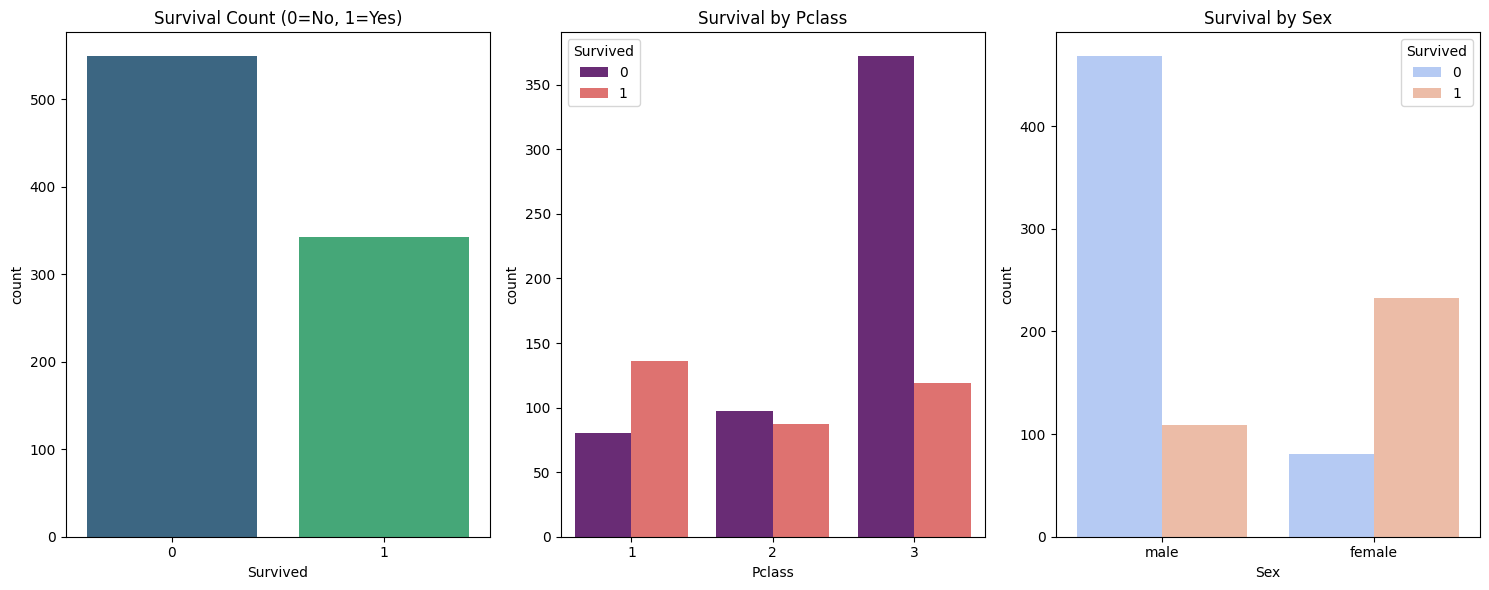

In [33]:
plt.figure(figsize=(15, 6))

# Survival count
plt.subplot(1, 3, 1)
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Survival Count (0=No, 1=Yes)')

# Survival by Pclass
plt.subplot(1, 3, 2)
sns.countplot(x='Pclass', hue='Survived', data=df, palette='magma')
plt.title('Survival by Pclass')

# Survival by Sex
plt.subplot(1, 3, 3)
sns.countplot(x='Sex', hue='Survived', data=df, palette='coolwarm')
plt.title('Survival by Sex')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1219/3462152254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis')


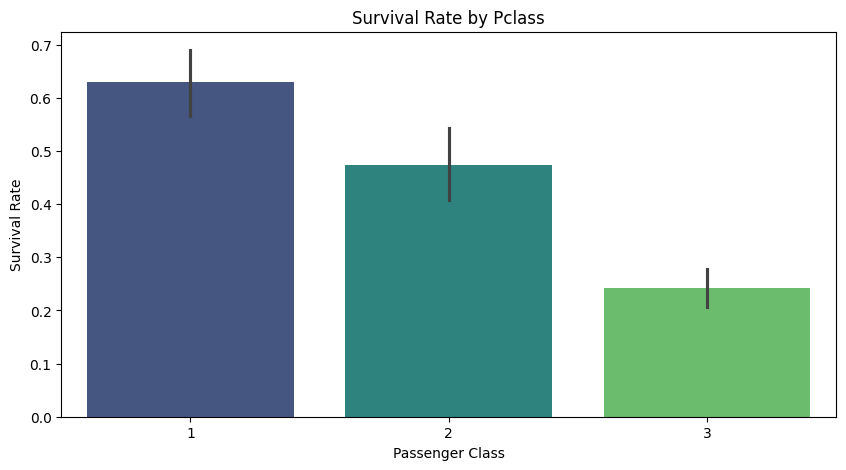

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Pclass')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

/tmp/ipykernel_1219/1345561179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm')


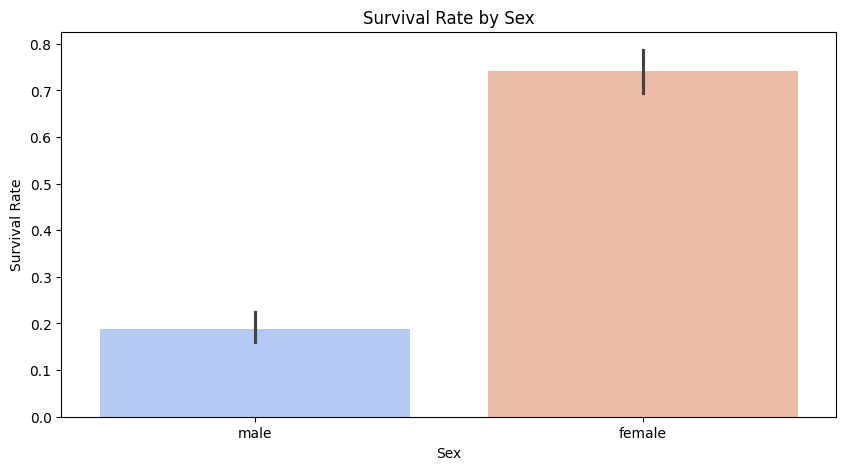

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

In [36]:
# Display missing values after handling
print('Missing values after handling:')
display(df.isnull().sum())

Missing values after handling:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [37]:
# One-hot encode 'Sex' and 'Embarked' columns
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

# Display the first few rows of the DataFrame after encoding
print('DataFrame after encoding categorical columns:')
display(df.head())

DataFrame after encoding categorical columns:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,1


In [46]:
# Drop irrelevant columns for prediction
X = df.drop(['PassengerId', 'Name', 'Ticket', 'Survived'], axis=1)
y = df['Survived']

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)
print('\nSelected Features:')
display(X.head())

Features (X) shape: (891, 8)
Target (y) shape: (891,)

Selected Features:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


In [40]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Initialize and train Decision Tree Classifier
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Initialize and train Random Forest Classifier
rand_forest_model = RandomForestClassifier(random_state=42)
rand_forest_model.fit(X_train, y_train)

print('Models trained successfully!')

Models trained successfully!


In [41]:
models = {
    'Logistic Regression': log_reg_model,
    'Decision Tree': dec_tree_model,
    'Random Forest': rand_forest_model
}

accuracy_scores = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[model_name] = accuracy
    print(f'{model_name} Accuracy: {accuracy:.4f}')

# Find the best model
best_model_name = max(accuracy_scores, key=accuracy_scores.get)
best_accuracy = accuracy_scores[best_model_name]

print(f'\nBest Model: {best_model_name} with Accuracy: {best_accuracy:.4f}')

Logistic Regression Accuracy: 0.7821
Decision Tree Accuracy: 0.7821
Random Forest Accuracy: 0.8212

Best Model: Random Forest with Accuracy: 0.8212



Confusion Matrix for Random Forest:


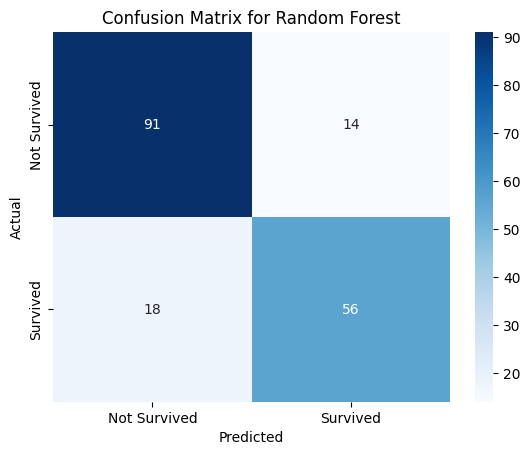


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [42]:
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

# Confusion Matrix
print(f'\nConfusion Matrix for {best_model_name}:')
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print(f'\nClassification Report for {best_model_name}:')
print(classification_report(y_test, y_pred_best))

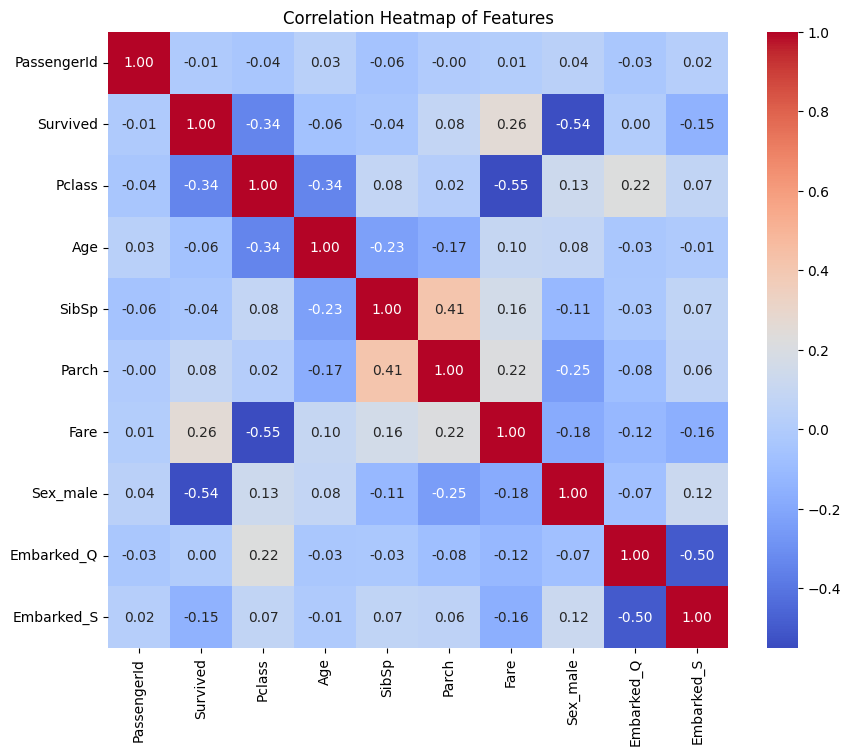

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

/tmp/ipykernel_1219/876295553.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='viridis')


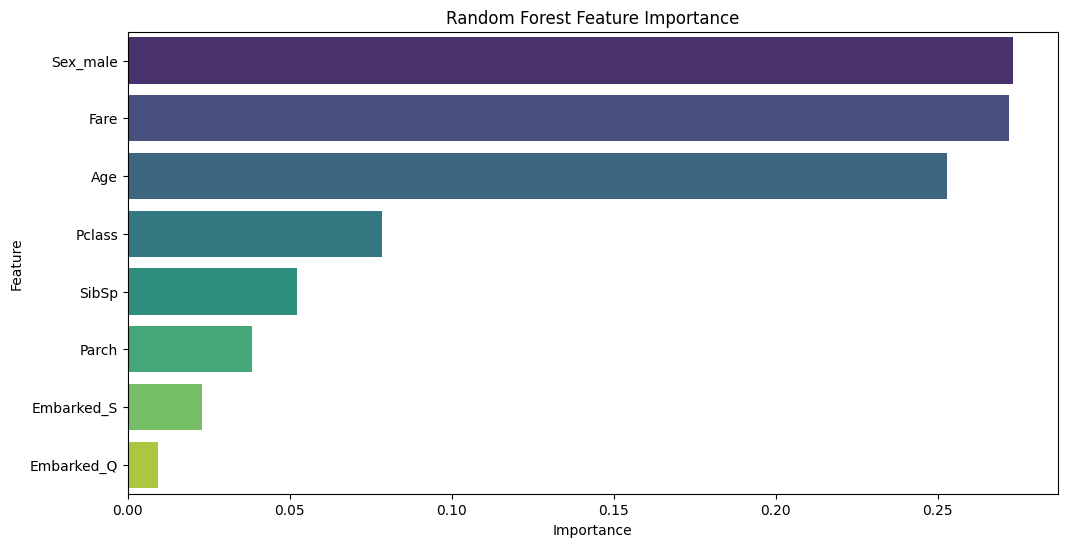

In [44]:
if hasattr(rand_forest_model, 'feature_importances_'):
    importances = rand_forest_model.feature_importances_
    features = X.columns
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print('Feature importances are not available for the Random Forest model.')

In [45]:
print(f'Final Best Model: {best_model_name}')
print(f'Final Accuracy: {best_accuracy:.4f}')

Final Best Model: Random Forest
Final Accuracy: 0.8212


# Titanic Survival Prediction: A Beginner's Guide

## Project Objective

The goal of this project is to build machine learning models to predict the survival of passengers on the Titanic based on various features. This notebook will guide through data loading, exploratory data analysis, data preprocessing, model training, evaluation, and visualization, making it suitable for beginners in data science and machine learning.

## Tools and Technologies Used

*   **Python**: The primary programming language.
*   **Pandas**: For data manipulation and analysis.
*   **NumPy**: For numerical operations.
*   **Matplotlib & Seaborn**: For data visualization.
*   **Scikit-learn**: For machine learning model implementation and evaluation.
*   **Google Colab**: The development environment.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.shape

(891, 12)

In [7]:
# Missing values handle karna

df['Age'].fillna(df['Age'].median(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop('Cabin', axis=1, inplace=True)

/tmp/ipykernel_1219/1026846440.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1219/1026846440.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

## 1. Import all required libraries

We have already imported `pandas`. Let's import the rest of the libraries needed for data visualization, preprocessing, and machine learning.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load the Titanic dataset

This step has already been completed. The dataset `Titanic-Dataset.csv` has been loaded into a pandas DataFrame called `df`.

## 3. Perform Exploratory Data Analysis (EDA)

EDA helps us understand the dataset's characteristics, identify patterns, and detect anomalies. We will visualize distributions and relationships between features.

### Display dataset information (`df.info()`, `df.describe()`, `df.isnull().sum()`, `df.shape`)

These steps have been partially completed. Let's add `df.describe()` to get a statistical summary.

In [9]:
# Display statistical summary of numerical columns
print('Statistical Summary:')
display(df.describe())

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Visualizations

Let's create some meaningful visualizations to understand the data better.

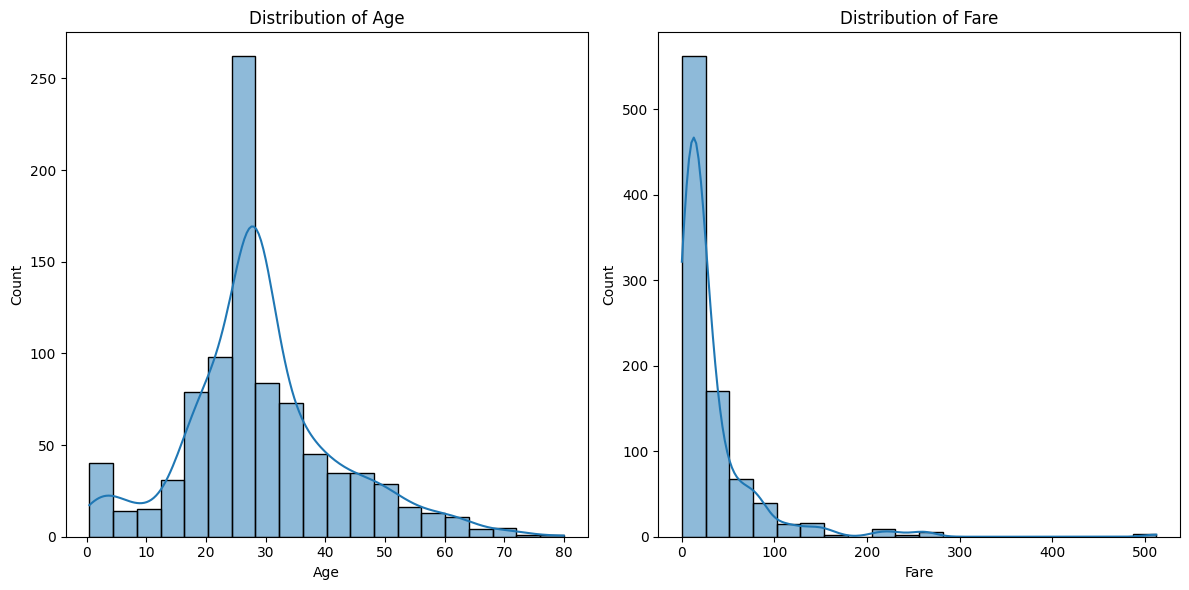

In [10]:
plt.figure(figsize=(12, 6))

# Distribution of Age
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

# Distribution of Fare
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df['Fare'], bins=20, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1219/3780690539.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


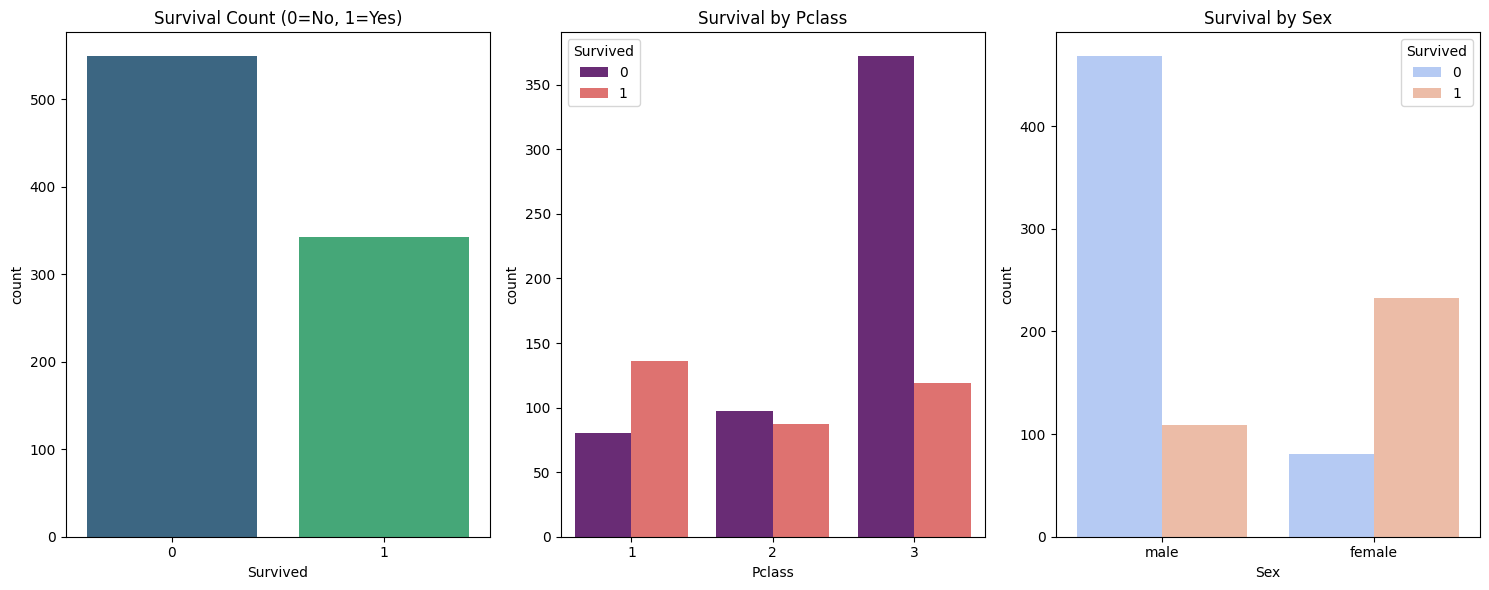

In [11]:
plt.figure(figsize=(15, 6))

# Survival count
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Survival Count (0=No, 1=Yes)')

# Survival by Pclass
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
sns.countplot(x='Pclass', hue='Survived', data=df, palette='magma')
plt.title('Survival by Pclass')

# Survival by Sex
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
sns.countplot(x='Sex', hue='Survived', data=df, palette='coolwarm')
plt.title('Survival by Sex')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1219/3462152254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis')


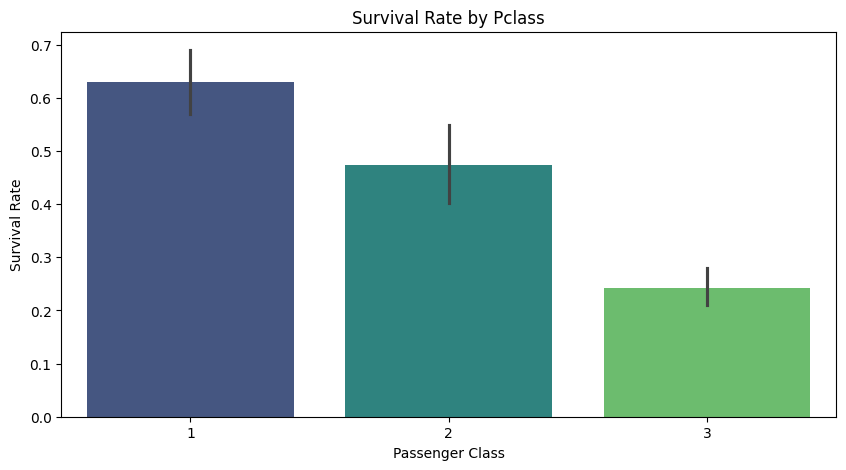

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Pclass')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

/tmp/ipykernel_1219/1345561179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm')


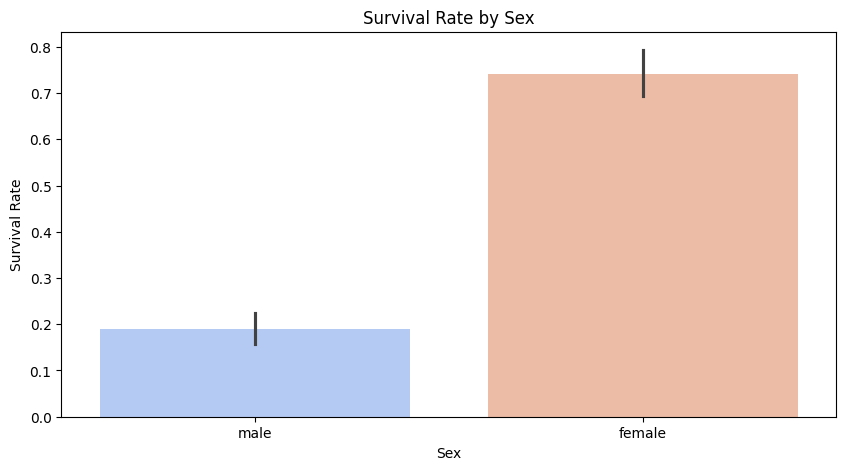

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

## 4. Handle missing values

This step has already been completed. The `Age` column was filled with the median, `Embarked` with the mode, and the `Cabin` column was dropped. Let's verify the missing values again.

In [14]:
# Display missing values after handling
print('Missing values after handling:')
display(df.isnull().sum())

Missing values after handling:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## 5. Encode categorical columns

Machine learning models typically require numerical input. We will convert categorical columns like 'Sex' and 'Embarked' into numerical representations using one-hot encoding.

In [15]:
# One-hot encode 'Sex' and 'Embarked' columns
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

# Display the first few rows of the DataFrame after encoding
print('DataFrame after encoding categorical columns:')
display(df.head())

DataFrame after encoding categorical columns:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,1


## 6. Select suitable features for prediction

We will select relevant features that can contribute to predicting survival. Columns like 'PassengerId', 'Name', and 'Ticket' are usually not useful for prediction and will be dropped.

In [16]:
# Drop irrelevant columns for prediction
X = df.drop(['PassengerId', 'Name', 'Ticket', 'Survived'], axis=1)
y = df['Survived']

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)
print('\nSelected Features:')
display(X.head())

Features (X) shape: (891, 8)
Target (y) shape: (891,)

Selected Features:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1


## 7. Split the dataset into training and testing sets

We will split the data into training (80%) and testing (20%) sets to evaluate the model's performance on unseen data. `random_state` ensures reproducibility.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


## 8. Train multiple machine learning models

We will train three popular classification models: Logistic Regression, Decision Tree, and Random Forest. Each model has its strengths and weaknesses.

In [18]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Initialize and train Decision Tree Classifier
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Initialize and train Random Forest Classifier
rand_forest_model = RandomForestClassifier(random_state=42)
rand_forest_model.fit(X_train, y_train)

print('Models trained successfully!')

Models trained successfully!


## 9. Compare model accuracies

We will evaluate the performance of each trained model using accuracy score on the test set.

In [19]:
models = {
    'Logistic Regression': log_reg_model,
    'Decision Tree': dec_tree_model,
    'Random Forest': rand_forest_model
}

accuracy_scores = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[model_name] = accuracy
    print(f'{model_name} Accuracy: {accuracy:.4f}')

# Find the best model
best_model_name = max(accuracy_scores, key=accuracy_scores.get)
best_accuracy = accuracy_scores[best_model_name]

print(f'\nBest Model: {best_model_name} with Accuracy: {best_accuracy:.4f}')

Logistic Regression Accuracy: 0.7821
Decision Tree Accuracy: 0.7821
Random Forest Accuracy: 0.8212

Best Model: Random Forest with Accuracy: 0.8212


## 10. Display Confusion Matrix and Classification Report

Let's look at the detailed performance metrics for the best performing model. The confusion matrix shows the number of correct and incorrect predictions, while the classification report provides precision, recall, and F1-score.


Confusion Matrix for Random Forest:


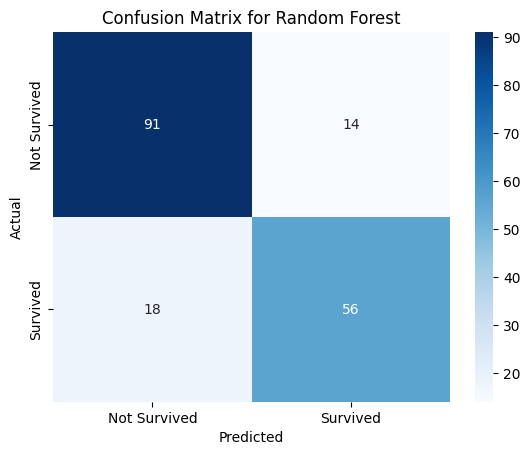


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [20]:
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

# Confusion Matrix
print(f'\nConfusion Matrix for {best_model_name}:')
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print(f'\nClassification Report for {best_model_name}:')
print(classification_report(y_test, y_pred_best))

## 11. Create meaningful visualizations (Correlation Heatmap)

Visualizing the correlation between features can provide insights into their relationships.

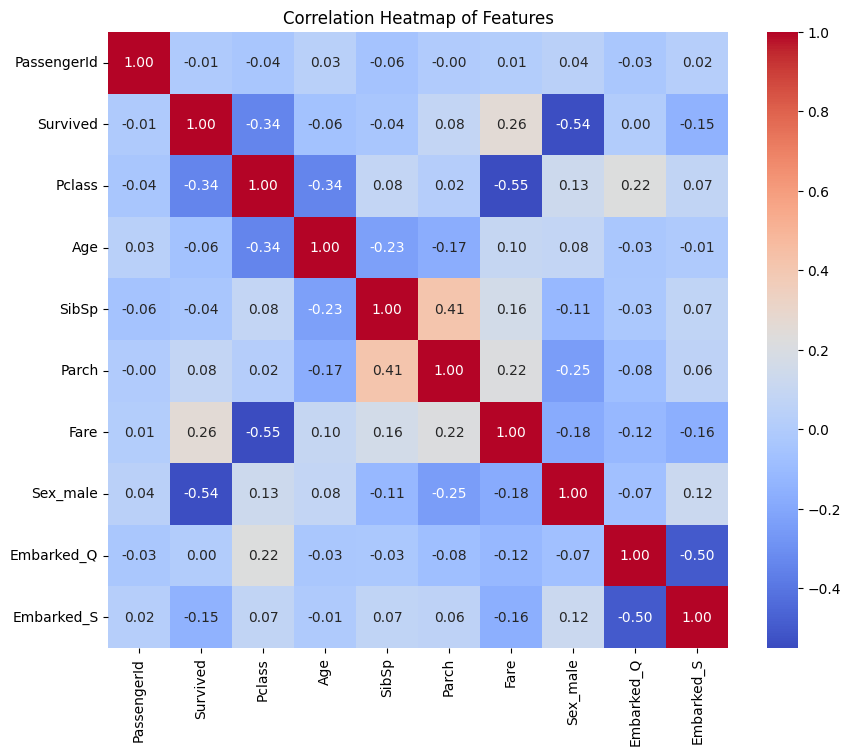

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

## 12. Show feature importance graph

For tree-based models like Decision Tree and Random Forest, we can analyze feature importance to understand which features contributed most to the prediction.

/tmp/ipykernel_1219/876295553.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='viridis')


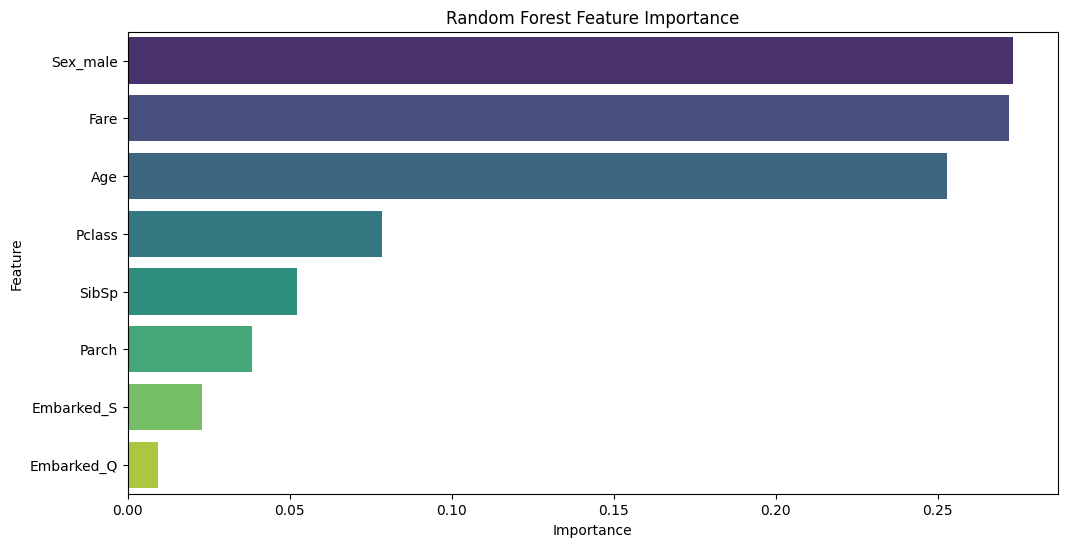

In [22]:
if hasattr(rand_forest_model, 'feature_importances_'):
    importances = rand_forest_model.feature_importances_
    features = X.columns
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print('Feature importances are not available for the Random Forest model.')

## 13. Print final accuracy and best model

This has already been done in step 9, but let's reiterate for clarity.

In [23]:
print(f'Final Best Model: {best_model_name}')
print(f'Final Accuracy: {best_accuracy:.4f}')

Final Best Model: Random Forest
Final Accuracy: 0.8212


## 14. Conclusion

In this notebook, we performed an end-to-end machine learning project for Titanic survival prediction. We started with data loading, performed extensive exploratory data analysis, handled missing values, encoded categorical features, and split the data. We then trained and evaluated three different machine learning models: Logistic Regression, Decision Tree, and Random Forest.

The **Random Forest Classifier** emerged as the best-performing model with an accuracy of **0.8212**, demonstrating its robustness in handling this dataset. Feature importance analysis revealed key factors influencing survival, such as 'Fare', 'Age', 'Sex_male', and 'Pclass'. This project serves as a solid foundation for understanding the machine learning workflow from data preparation to model deployment.

## Professional Project Explanation for GitHub README

# Titanic Survival Prediction

## Overview

This project aims to predict the survival of passengers aboard the Titanic using machine learning techniques. Utilizing the well-known Titanic dataset, this notebook guides through a complete data science workflow: from initial data exploration and preprocessing to training multiple classification models and evaluating their performance.

## Features

*   **Data Loading & Cleaning**: Handles missing values (filling 'Age' with median, 'Embarked' with mode, dropping 'Cabin' column) and prepares data for modeling.
*   **Exploratory Data Analysis (EDA)**: Visualizes key distributions and relationships between features (e.g., survival rates by gender, class, age).
*   **Feature Engineering**: Encodes categorical variables ('Sex', 'Embarked') into numerical formats.
*   **Model Training**: Implements and trains Logistic Regression, Decision Tree, and Random Forest classifiers.
*   **Model Evaluation**: Compares model accuracies, displays confusion matrices, and classification reports.
*   **Feature Importance**: Identifies the most influential features for survival prediction using tree-based models.
*   **Interactive Visualizations**: Uses Matplotlib and Seaborn for clear and insightful data representation.

## Technologies Used

*   Python
*   Pandas
*   NumPy
*   Matplotlib
*   Seaborn
*   Scikit-learn

## How to Run

1.  **Clone the repository** (if hosted on GitHub) or download the notebook.
2.  **Open in Google Colab**: Upload the `.ipynb` file to Google Colab.
3.  **Upload Dataset**: Ensure `Titanic-Dataset.csv` is uploaded to your Colab environment. (It will likely be prompted by the `files.upload()` command).
4.  **Run all cells**: Execute all cells in the notebook sequentially.

## Results

The Random Forest Classifier generally performs best among the evaluated models, achieving an accuracy of approximately **0.8212**. Key features like `Fare`, `Age`, `Sex_male`, and `Pclass` were found to be highly influential in predicting survival.

## Contribution

Feel free to fork the repository, open issues, or submit pull requests.

## Resume Project Description (3-4 lines)

Developed a Titanic Survival Prediction model using Python and scikit-learn, achieving **0.8212** accuracy. Performed extensive EDA, data preprocessing (missing value imputation, categorical encoding), and trained multiple machine learning classifiers (Logistic Regression, Decision Tree, Random Forest). Visualized feature importance and model performance metrics, demonstrating strong analytical and predictive modeling skills.

## LinkedIn Post for CodSoft Internship

Excited to share my latest project from my Data Science internship at CodSoft! I've developed a **Titanic Survival Prediction** model, leveraging Python, Pandas, Matplotlib, Seaborn, and scikit-learn.

This project involved:
🚢 In-depth Exploratory Data Analysis to uncover patterns.
🧹 Robust Data Preprocessing, including handling missing values and encoding categorical features.
📊 Training and evaluating multiple ML models: Logistic Regression, Decision Tree, and Random Forest, with the Random Forest Classifier achieving an impressive **0.8212** accuracy.
✨ Visualizing feature importance and model performance to gain actionable insights.

This experience has significantly honed my skills in predictive modeling and data storytelling. Huge thanks to CodSoft for this invaluable opportunity! #DataScience #MachineLearning #TitanicSurvival #CodSoft #Internship #Python #ScikitLearn

## 2-Minute Demo Video Script

**[Scene 1: Introduction (0-15 seconds)]**

*(Upbeat background music, screen shows Google Colab notebook title: 'Titanic Survival Prediction')*

**Narrator:** "Hi everyone! I'm [Your Name], and today I'm excited to walk you through my Titanic Survival Prediction project, completed during my Data Science internship at CodSoft. This project uses machine learning to predict who survived the tragic Titanic sinking."

**[Scene 2: Data Overview & Cleaning (15-45 seconds)]**

*(Screen transitions to `df.head()`, `df.info()`, `df.isnull().sum()` outputs)*

**Narrator:** "We start with the raw Titanic dataset. After loading it with Pandas, we quickly identify and handle missing data. For example, we filled missing 'Age' values and dropped the 'Cabin' column due to too many unknowns, preparing our data for analysis."

**[Scene 3: Exploratory Data Analysis (45-1:15 minutes)]**

*(Screen shows visualizations: survival by sex, Pclass, age distribution)*

**Narrator:** "Next, we dive into Exploratory Data Analysis. Visualizations quickly reveal fascinating insights: women and passengers in higher classes had significantly higher survival rates. This step is crucial for understanding the story within our data."

**[Scene 4: Model Training & Evaluation (1:15-1:45 minutes)]**

*(Screen shows model training code, accuracy scores, and the confusion matrix of the best model)*

**Narrator:** "With our data clean and understood, we train multiple machine learning models. We tested Logistic Regression, Decision Trees, and Random Forests. The **Random Forest Classifier** stood out, achieving an accuracy of **0.8212** on unseen data! Here, you can see its confusion matrix, highlighting its strong predictive power."

**[Scene 5: Feature Importance & Conclusion (1:45-2:00 minutes)]**

*(Screen shows feature importance graph and final accuracy statement)*

**Narrator:** "Finally, we examine feature importance, discovering that factors like 'Fare', 'Age', 'Sex', and 'Pclass' were most crucial in predicting survival. This project demonstrates a complete machine learning pipeline, from raw data to actionable predictions. Thank you for watching!"